   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.9/134.9 MB 7.3 MB/s eta 0:00:00
Device: cuda
Loading DINOv2 (ViT-L/14)...
Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip
Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vitl14/dinov2_vitl14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vitl14_pretrain.pth


100%|██████████| 1.13G/1.13G [00:06<00:00, 195MB/s]


Loading CLIP (ViT-L/14)...


config.json:   0%|          | 0.00/4.52k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.71GB            

...

  (1317.1s for this category)

[5/8] mvtec_ad_2/sheet_metal


  (404.9s for this category)

[6/8] mvtec_ad_2/vial


  (368.3s for this category)

[7/8] mvtec_ad_2/wallplugs


  (628.1s for this category)

[8/8] mvtec_ad_2/walnuts


  (1645.7s for this category)

######################################################################
# MVTEC_AD_2 DATASET COMPLETE — interim results
######################################################################

-- Table 9 (few-shot), mvtec_ad_2 --
| category    |   1shot_acc |   1shot_f1 |   5shot_acc |   5shot_f1 |   10shot_acc |   10shot_f1 |
|:------------|------------:|-----------:|------------:|-----------:|-------------:|------------:|
| can         |       61    |      74.07 |       66.18 |      76.01 |        67.04 |       75.82 |
| fabric      |       70    |      79.25 |       76.85 |      82.29 |        80    |       85.1  |
| fruit_jelly |       80.77 |      88.72 |       90.86 |      94.48 |        92.33 |       95.58 |
| rice        |       74.46 |      83.37 |       77.7  |      85.68 |        82.32 |       88.58 |
| sheet_metal |       81.25 |      89.45 |       83.46 |      90.82 |        86.81 |       92.81 |
| vial        |       82.17 |      89.31 |      

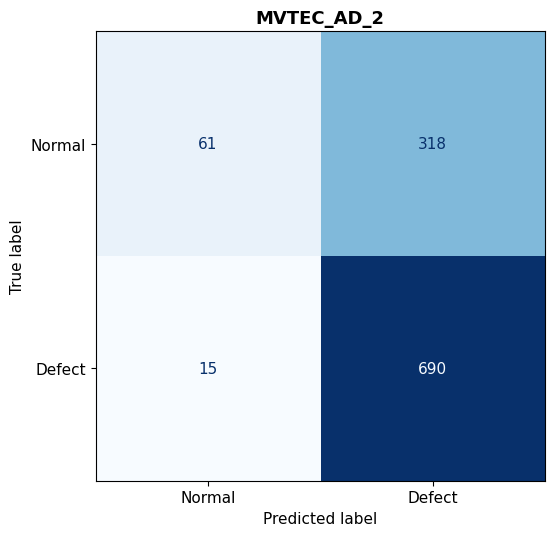

Saved: /mnt/user-data/outputs/confusion_matrices.png


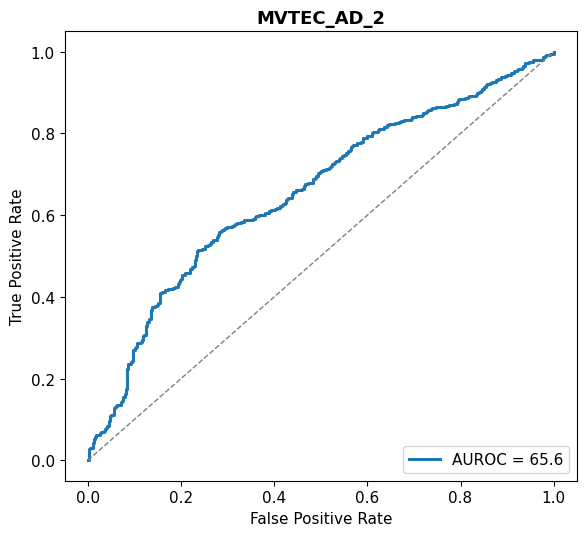

Saved: /mnt/user-data/outputs/roc_curves.png


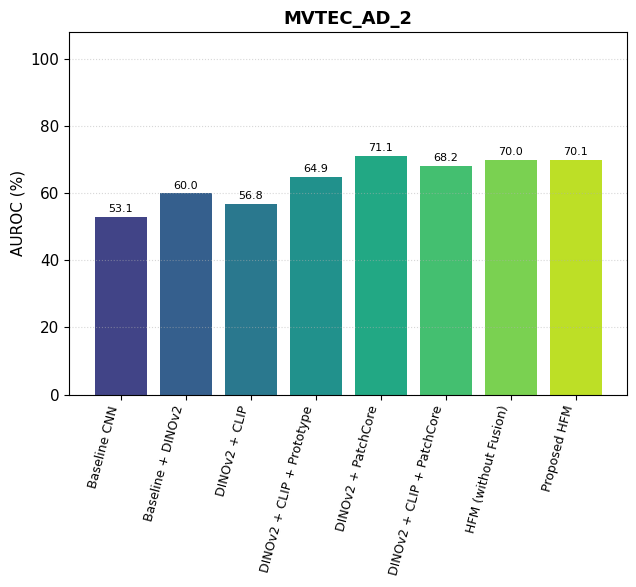

Saved: /mnt/user-data/outputs/ablation_barchart.png

XAI — PatchCore anomaly localization on 5 samples per dataset


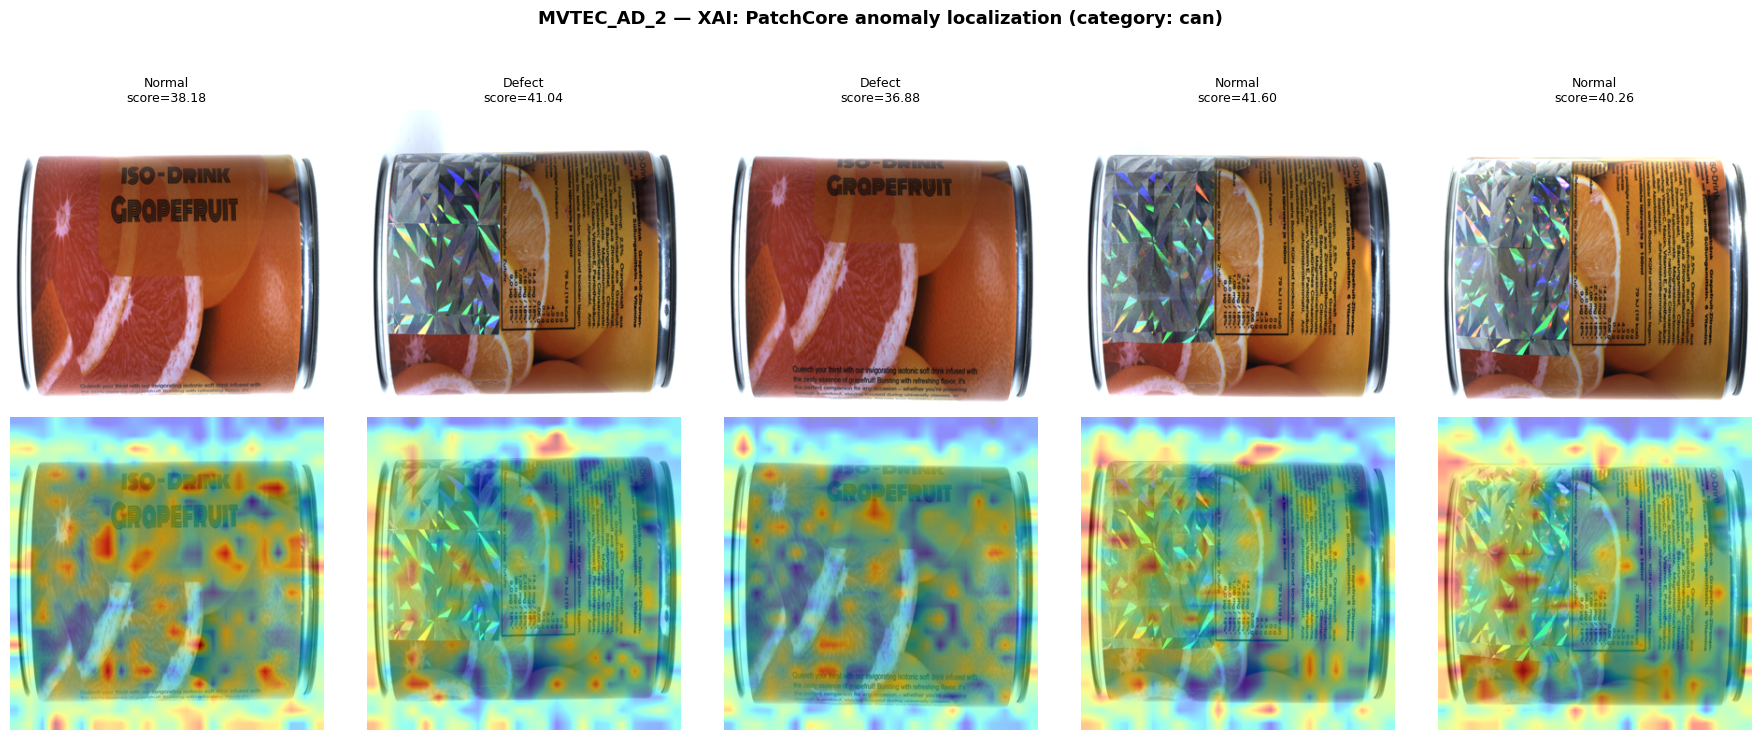

Saved: /mnt/user-data/outputs/xai_samples_mvtec_ad_2.png

Saving model bundle for the standalone dashboard
Saved model bundle: /mnt/user-data/outputs/hfm_model_bundle.pt (261.8 MB, 8 categories)
Upload this .pt file into the 'hfm_dashboard.py' Streamlit app (run separately: `streamlit run hfm_dashboard.py`) to analyze new images.


In [ ]:

# -*- coding: utf-8 -*-
# HFM for MVTec AD 2 (2026)
# Authors: Hedieh Sajedi , Abolfazl Khojasteh Abkenar


!pip install -q faiss-gpu transformers scikit-learn thop kaggle

import os, copy, time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
import torchvision.transforms.functional as TF
import torchvision.models as tvm
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (roc_auc_score, accuracy_score, precision_score,
                              recall_score, f1_score)
from sklearn.linear_model import LogisticRegression
import faiss
from tqdm import tqdm
from PIL import Image
from transformers import CLIPModel, CLIPProcessor
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings("ignore")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BASE_DATASETS_DIR = "./industrial_datasets"
IMG_EXTS = ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')
IMG_SIZE = 336
RESIZE_SIZE = 384
USE_FP16 = True
NUM_DINO_LAYERS = 4
GOOD_NAMES = ("good", "ok", "normal")
MASK_DIR_NAMES = ("ground_truth", "gt", "masks")
CLIP_MODEL_NAME = "openai/clip-vit-large-patch14"
FEWSHOT_KS = [1, 5, 10]
FEWSHOT_SEEDS = 5
INFER_TIMING_RUNS = 50
INFER_TIMING_WARMUP = 10

DATASETS_TO_RUN = ["mvtec_ad_2"]  

MVTEC_AD2_TAR_URL = "https://www.mydrive.ch/shares/150997/701c90d3aea6588f404936e32a674602/download/466712769-1743429042/mvtec_ad_2.tar.gz"
MVTEC_AD2_CATEGORIES = None      
MVTEC_AD2_MERGE_VALIDATION_INTO_TRAIN = True
print(f"Device: {DEVICE}")

def ensure_kaggle_credentials():
    if os.path.exists(os.path.expanduser('~/.kaggle/kaggle.json')):
        return
    from google.colab import files
    print("Upload your kaggle.json (Kaggle account -> Settings -> Create New API Token):")
    files.upload()
    os.system("mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json")
    os.system("pip install -q --upgrade kaggle")


def find_category_dirs_generic(root):
    cats = []
    for dirpath, dirnames, _ in os.walk(root):
        if "train" in dirnames and "test" in dirnames:
            train_dir = os.path.join(dirpath, "train")
            sub = [d.lower() for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))]
            if any(s in GOOD_NAMES for s in sub):
                cats.append(dirpath)
    return sorted(cats)

def find_mask_dir(cat_dir):
    for name in MASK_DIR_NAMES:
        p = os.path.join(cat_dir, name)
        if os.path.isdir(p):
            return p
    return None

def get_mvtec_style_paths_with_masks(cat_dir):
    train_root = os.path.join(cat_dir, "train")
    good_name = next((c for c in GOOD_NAMES if os.path.isdir(os.path.join(train_root, c))), None)
    train_paths = []
    if good_name:
        gd = os.path.join(train_root, good_name)
        train_paths = [os.path.join(gd, f) for f in sorted(os.listdir(gd)) if f.lower().endswith(IMG_EXTS)]

    mask_root = find_mask_dir(cat_dir)
    test_root = os.path.join(cat_dir, "test")
    test_paths, test_labels, mask_paths, defect_types = [], [], [], []
    if os.path.isdir(test_root):
        for defect_type in sorted(os.listdir(test_root)):
            d = os.path.join(test_root, defect_type)
            if not os.path.isdir(d):
                continue
            is_good = defect_type.lower() in GOOD_NAMES
            label = 0 if is_good else 1
            for f in sorted(os.listdir(d)):
                if not f.lower().endswith(IMG_EXTS):
                    continue
                test_paths.append(os.path.join(d, f))
                test_labels.append(label)
                defect_types.append("good" if is_good else defect_type)
                mp = None
                if (not is_good) and mask_root is not None:
                    stem = os.path.splitext(f)[0]
                    cand = [os.path.join(mask_root, defect_type, stem + "_mask" + e) for e in IMG_EXTS] + \
                           [os.path.join(mask_root, defect_type, stem + e) for e in IMG_EXTS]
                    for c in cand:
                        if os.path.exists(c):
                            mp = c
                            break
                mask_paths.append(mp)
    return train_paths, test_paths, test_labels, mask_paths, defect_types


def _download_kaggle_dataset(folder_name, slug):
    root = os.path.join(BASE_DATASETS_DIR, folder_name)
    os.makedirs(BASE_DATASETS_DIR, exist_ok=True)
    if find_category_dirs_generic(root):
        print(f"{folder_name} already present.")
        return root
    print(f"{folder_name} not found. Downloading from Kaggle ({slug})...")
    ensure_kaggle_credentials()
    os.system(f"kaggle datasets download -d {slug} -p {root} --unzip")
    if not find_category_dirs_generic(root):
        raise RuntimeError(f"{folder_name} download failed — check Kaggle credentials/slug, "
                            f"or the mirror's folder layout differs from the expected "
                            f"train/{{good,ok,normal}}, test/{{good,<defect>}} structure.")
    return root

def download_mvtec():
    return _download_kaggle_dataset("MVTec", MVTEC_KAGGLE_SLUG)

def download_btad():
    return _download_kaggle_dataset("BTAD", BTAD_KAGGLE_SLUG)

def download_mpdd():
    return _download_kaggle_dataset("MPDD", MPDD_KAGGLE_SLUG)

def collect_kaggle_style_tasks(dataset_name, root):
    cats = find_category_dirs_generic(root)
    tasks = []
    for cat_dir in cats:
        name = os.path.basename(cat_dir)
        train_p, test_p, test_y, mask_p, dtypes = get_mvtec_style_paths_with_masks(cat_dir)
        if train_p and test_p:
            tasks.append((dataset_name, name, train_p, test_p, test_y, mask_p, dtypes))
    return tasks


def _list_imgs(d):
    if not os.path.isdir(d):
        return []
    return sorted(f for f in os.listdir(d) if f.lower().endswith(IMG_EXTS))

def discover_mvtec_ad2_categories(root):

    if not os.path.isdir(root):
        return []
    return sorted(
        name for name in os.listdir(root)
        if os.path.isdir(os.path.join(root, name, "train", "good"))
    )

def find_mvtec_ad2_mask(gt_dir, image_filename):

    if not os.path.isdir(gt_dir):
        return None
    stem = os.path.splitext(image_filename)[0]
    search_dirs = [gt_dir, os.path.join(gt_dir, "bad")]
    for d in search_dirs:
        if not os.path.isdir(d):
            continue
        for e in IMG_EXTS:
            for cand in (os.path.join(d, stem + "_mask" + e), os.path.join(d, stem + e)):
                if os.path.exists(cand):
                    return cand
    import glob
    for d in search_dirs:
        if not os.path.isdir(d):
            continue
        matches = sorted(m for m in glob.glob(os.path.join(d, stem + "*")) if m.lower().endswith(IMG_EXTS))
        if matches:
            return matches[0]
    return None

def get_mvtec_ad2_category_paths(cat_dir, merge_validation_into_train=True):
    train_dir = os.path.join(cat_dir, "train", "good")
    val_dir = os.path.join(cat_dir, "validation", "good")
    train_paths = [os.path.join(train_dir, f) for f in _list_imgs(train_dir)]
    if merge_validation_into_train:
        train_paths += [os.path.join(val_dir, f) for f in _list_imgs(val_dir)]

    test_public_dir = os.path.join(cat_dir, "test_public")
    good_dir = os.path.join(test_public_dir, "good")
    bad_dir = os.path.join(test_public_dir, "bad")
    gt_dir = os.path.join(test_public_dir, "ground_truth")

    test_paths, test_labels, mask_paths, defect_types = [], [], [], []
    for f in _list_imgs(good_dir):
        test_paths.append(os.path.join(good_dir, f))
        test_labels.append(0)
        mask_paths.append(None)
        defect_types.append("good")
    for f in _list_imgs(bad_dir):
        test_paths.append(os.path.join(bad_dir, f))
        test_labels.append(1)
        defect_types.append("bad")
        mask_paths.append(find_mvtec_ad2_mask(gt_dir, f))
    return train_paths, test_paths, test_labels, mask_paths, defect_types

def download_mvtec_ad2():
    parent = os.path.join(BASE_DATASETS_DIR, "mvtec_ad_2_download")
    root = os.path.join(parent, "mvtec_ad_2")  
    os.makedirs(parent, exist_ok=True)

    if discover_mvtec_ad2_categories(root):
        print("MVTec AD 2 already present.")
        return root

    print("MVTec AD 2 not found. Downloading tar.gz (this is a large file, may take a while)...")
    tar_path = os.path.join(parent, "mvtec_ad_2.tar.gz")
    os.system(f'wget -q --no-check-certificate -U "Mozilla/5.0" "{MVTEC_AD2_TAR_URL}" -O {tar_path}')
    if not os.path.exists(tar_path) or os.path.getsize(tar_path) == 0:
        raise RuntimeError("MVTec AD 2 download failed — check network access to the download URL.")

    print("Extracting...")
    os.system(f"tar -xzf {tar_path} -C {parent}")

    if not discover_mvtec_ad2_categories(root):
        
        if discover_mvtec_ad2_categories(parent):
            root = parent
        else:
            raise RuntimeError(f"MVTec AD 2 extraction failed or unexpected folder layout under {parent}.")
    return root

def collect_mvtec_ad2_tasks(root):
    cat_names = MVTEC_AD2_CATEGORIES if MVTEC_AD2_CATEGORIES else discover_mvtec_ad2_categories(root)
    if not cat_names:
        print(f"  [mvtec_ad_2] no category folders found under {root}")
    tasks = []
    for cat_name in cat_names:
        cat_dir = os.path.join(root, cat_name)
        if not os.path.isdir(cat_dir):
            print(f"  [mvtec_ad_2] category '{cat_name}' not found at {cat_dir}, skipping.")
            continue
        train_p, test_p, test_y, mask_p, dtypes = get_mvtec_ad2_category_paths(
            cat_dir, MVTEC_AD2_MERGE_VALIDATION_INTO_TRAIN)
        if train_p and test_p:
            n_good = sum(1 for y in test_y if y == 0)
            n_bad = sum(1 for y in test_y if y == 1)
            print(f"  [mvtec_ad_2] {cat_name}: {len(train_p)} train, "
                  f"{len(test_p)} test_public ({n_good} good / {n_bad} bad)")
            tasks.append(("mvtec_ad_2", cat_name, train_p, test_p, test_y, mask_p, dtypes))
        else:
            print(f"  [mvtec_ad_2] category '{cat_name}' has no usable train/test_public images, skipping.")
    return tasks


def download_visa():
    root = os.path.join(BASE_DATASETS_DIR, "VisA")
    os.makedirs(root, exist_ok=True)

    already_extracted = any(
        os.path.isdir(os.path.join(root, d, "Data", "Images"))
        for d in os.listdir(root) if os.path.isdir(os.path.join(root, d))
    ) if os.path.isdir(root) else False

    if not already_extracted:
        print("VisA not found. Downloading tar (~1.4GB, may take a while)...")
        tar_path = os.path.join(BASE_DATASETS_DIR, "VisA_20220922.tar")
        os.system(f"wget -q {VISA_TAR_URL} -O {tar_path}")
        if not os.path.exists(tar_path) or os.path.getsize(tar_path) == 0:
            raise RuntimeError("VisA tar download failed — check network access to the S3 URL.")
        os.system(f"tar -xf {tar_path} -C {root}")
    else:
        print("VisA already present.")

    csv_path = os.path.join(root, "split_csv_1cls.csv")
    if not os.path.exists(csv_path):
        os.system(f"wget -q {VISA_SPLIT_CSV_URL} -O {csv_path}")
        if not os.path.exists(csv_path) or os.path.getsize(csv_path) == 0:
            if os.path.exists(csv_path):
                os.remove(csv_path)
            print("Could not fetch the official VisA split CSV — falling back to a seeded "
                  "synthetic train/test split per category. Results under the fallback are "
                  "NOT directly comparable to papers using the official split.")
    return root

def discover_visa_categories(visa_root):
    cats = []
    for name in sorted(os.listdir(visa_root)):
        d = os.path.join(visa_root, name)
        if os.path.isdir(os.path.join(d, "Data", "Images")):
            cats.append(name)
    return cats

def load_visa_split_csv(visa_root):
    csv_path = os.path.join(visa_root, "split_csv_1cls.csv")
    if not os.path.exists(csv_path):
        return None
    try:
        df = pd.read_csv(csv_path)
        needed = {"object", "split", "label", "image"}
        if not needed.issubset(set(c.lower() for c in df.columns)):
            return None
        df.columns = [c.lower() for c in df.columns]
        return df
    except Exception as e:
        print(f"Could not parse VisA split CSV ({e}); falling back to synthetic split.")
        return None

def _visa_mask_for(visa_root, category_name, image_rel_path, is_anomaly):

    if not is_anomaly:
        return None
    stem = os.path.splitext(os.path.basename(image_rel_path))[0]
    for ext in IMG_EXTS:
        cand = os.path.join(visa_root, category_name, "Data", "Masks", "Anomaly", stem + ext)
        if os.path.exists(cand):
            return cand
    return None

def get_visa_paths(visa_root, category_name, split_df):

    if split_df is not None:
        sub = split_df[split_df["object"] == category_name]
        if len(sub) > 0:
            train_paths, test_paths, test_labels, mask_paths, defect_types = [], [], [], [], []
            for _, r in sub.iterrows():
                full = os.path.join(visa_root, r["image"])
                if str(r["split"]).lower() == "train":
                    train_paths.append(full)
                else:
                    is_anom = str(r["label"]).lower() != "normal"
                    label = 1 if is_anom else 0
                    test_paths.append(full)
                    test_labels.append(label)
                    defect_types.append("anomaly" if is_anom else "good")
                    mask_paths.append(_visa_mask_for(visa_root, category_name, r["image"], is_anom))
            return train_paths, test_paths, test_labels, mask_paths, defect_types


    normal_dir = os.path.join(visa_root, category_name, "Data", "Images", "Normal")
    anomaly_dir = os.path.join(visa_root, category_name, "Data", "Images", "Anomaly")
    normal_files = sorted(f for f in os.listdir(normal_dir) if f.lower().endswith(IMG_EXTS)) \
        if os.path.isdir(normal_dir) else []
    anomaly_files = sorted(f for f in os.listdir(anomaly_dir) if f.lower().endswith(IMG_EXTS)) \
        if os.path.isdir(anomaly_dir) else []

    rng = np.random.RandomState(0)
    normal_files = list(rng.permutation(normal_files))
    n_train = int(len(normal_files) * VISA_SYNTHETIC_TRAIN_FRAC)

    train_paths = [os.path.join(normal_dir, f) for f in normal_files[:n_train]]
    test_paths = [os.path.join(normal_dir, f) for f in normal_files[n_train:]] + \
                 [os.path.join(anomaly_dir, f) for f in anomaly_files]
    test_labels = [0] * (len(normal_files) - n_train) + [1] * len(anomaly_files)
    defect_types = ["good"] * (len(normal_files) - n_train) + ["anomaly"] * len(anomaly_files)
    mask_paths = [None] * (len(normal_files) - n_train) + \
                 [_visa_mask_for(visa_root, category_name, f, True) for f in anomaly_files]
    return train_paths, test_paths, test_labels, mask_paths, defect_types

def collect_visa_tasks():
    root = download_visa()
    split_df = load_visa_split_csv(root)
    split_kind_used = "official" if split_df is not None else "synthetic"
    cats = discover_visa_categories(root)
    tasks = []
    for name in cats:
        train_p, test_p, test_y, mask_p, dtypes = get_visa_paths(root, name, split_df)
        if train_p and test_p:
            tasks.append(("visa", name, train_p, test_p, test_y, mask_p, dtypes))
    print(f"VisA: using '{split_kind_used}' split for all categories.")
    return tasks

def collect_all_dataset_tasks():
    all_tasks = []
    if "mvtec_ad_2" in DATASETS_TO_RUN:
        print("\nPreparing dataset: mvtec_ad_2")
        root = download_mvtec_ad2()
        t = collect_mvtec_ad2_tasks(root)
        print(f"  -> {len(t)} categories found for mvtec_ad_2")
        all_tasks.extend(t)
    if "mvtec" in DATASETS_TO_RUN:
        print("\nPreparing dataset: mvtec")
        root = download_mvtec()
        t = collect_kaggle_style_tasks("mvtec", root)
        print(f"  -> {len(t)} categories found for mvtec")
        all_tasks.extend(t)
    if "visa" in DATASETS_TO_RUN:
        print("\nPreparing dataset: visa")
        t = collect_visa_tasks()
        print(f"  -> {len(t)} categories found for visa")
        all_tasks.extend(t)
    if "btad" in DATASETS_TO_RUN:
        print("\nPreparing dataset: btad")
        root = download_btad()
        t = collect_kaggle_style_tasks("btad", root)
        print(f"  -> {len(t)} categories found for btad")
        all_tasks.extend(t)
    if "mpdd" in DATASETS_TO_RUN:
        print("\nPreparing dataset: mpdd")
        root = download_mpdd()
        t = collect_kaggle_style_tasks("mpdd", root)
        print(f"  -> {len(t)} categories found for mpdd")
        all_tasks.extend(t)
    print(f"\nTotal categories across all datasets: {len(all_tasks)}")
    return all_tasks


print("Loading DINOv2 (ViT-L/14)...")
dinov2_model = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitl14').to(DEVICE).eval()
if USE_FP16:
    dinov2_model = dinov2_model.half()

print("Loading CLIP (ViT-L/14)...")
clip_model = CLIPModel.from_pretrained(CLIP_MODEL_NAME).to(DEVICE).eval()
clip_processor = CLIPProcessor.from_pretrained(CLIP_MODEL_NAME)

DINO_DIM = 1024
CLIP_DIM = clip_model.config.projection_dim

def get_clip_image_features(pixel_values):

    vision_outputs = clip_model.vision_model(pixel_values=pixel_values)
    pooled_output = vision_outputs.pooler_output
    image_features = clip_model.visual_projection(pooled_output)
    return image_features.float()

class FusionClassifier(nn.Module):
    def __init__(self, in_dim=DINO_DIM + CLIP_DIM, hidden=256):
        super().__init__()
        self.fuse = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.GELU(),
            nn.Linear(hidden, hidden), nn.GELU(),
        )
        self.classifier = nn.Linear(hidden, 1)

    def forward(self, x):
        return self.classifier(self.fuse(x)).squeeze(-1)

fusion_head = FusionClassifier().to(DEVICE).eval()
if USE_FP16:
    fusion_head = fusion_head.half()

BASELINE_CNN = tvm.resnet50(weights=tvm.ResNet50_Weights.IMAGENET1K_V2).to(DEVICE).eval()
BASELINE_CNN.fc = nn.Identity()


class ImageDataset(Dataset):
    def __init__(self, file_paths):
        self.file_paths = file_paths
        self.dinov2_norm = T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        self.resize_crop = T.Compose([T.Resize(RESIZE_SIZE), T.CenterCrop(IMG_SIZE)])

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        img = Image.open(self.file_paths[idx]).convert("RGB")
        img = self.resize_crop(img)
        t = self.dinov2_norm(TF.to_tensor(img))
        return {"dino": t}

def extract_cls_embeddings(paths, desc="cls", batch_size=32):
    if len(paths) == 0:
        return torch.zeros((0, DINO_DIM))
    loader = DataLoader(ImageDataset(paths), batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    embs = []
    with torch.no_grad():
        for b in tqdm(loader, desc=desc, leave=False):
            dino_in = b["dino"].to(DEVICE)
            if USE_FP16:
                dino_in = dino_in.half()
            feats = dinov2_model.get_intermediate_layers(dino_in, n=1, reshape=False, return_class_token=True)
            embs.append(feats[0][1].float().cpu())
    return torch.cat(embs, dim=0)

def extract_patch_grid(paths, desc="patch", batch_size=16):
    if len(paths) == 0:
        return torch.zeros((0, 1, 1, 1))
    loader = DataLoader(ImageDataset(paths), batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    grid_size = IMG_SIZE // 14
    all_grids = []
    with torch.no_grad():
        for b in tqdm(loader, desc=desc, leave=False):
            dino_in = b["dino"].to(DEVICE)
            if USE_FP16:
                dino_in = dino_in.half()
            layers = dinov2_model.get_intermediate_layers(dino_in, n=NUM_DINO_LAYERS, reshape=False, return_class_token=False)
            p = torch.stack(layers, dim=0).float().mean(dim=0)
            b_, n_, d_ = p.shape
            grid = p.permute(0, 2, 1).reshape(b_, d_, grid_size, grid_size)
            all_grids.append(grid.cpu())
    return torch.cat(all_grids, dim=0)

def extract_clip_image_embeds(paths, batch_size=32):
    if len(paths) == 0:
        return torch.zeros((0, CLIP_DIM))
    embs = []
    with torch.no_grad():
        for i in tqdm(range(0, len(paths), batch_size), desc="clip-img", leave=False):
            batch_imgs = [Image.open(p).convert("RGB") for p in paths[i:i+batch_size]]
            inputs = clip_processor(images=batch_imgs, return_tensors="pt").to(DEVICE)
            feats = get_clip_image_features(inputs["pixel_values"])
            feats = feats / feats.norm(dim=-1, keepdim=True)
            embs.append(feats.cpu())
    return torch.cat(embs, dim=0)

def clip_text_embeds(prompts):

    with torch.no_grad():
        inputs = clip_processor(text=prompts, return_tensors="pt", padding=True).to(DEVICE)
        text_outputs = clip_model.text_model(input_ids=inputs["input_ids"],
                                              attention_mask=inputs.get("attention_mask"))
        pooled_output = text_outputs.pooler_output
        feats = clip_model.text_projection(pooled_output)
        feats = feats / feats.norm(dim=-1, keepdim=True)
    return feats.float().cpu()


def profile_model_complexity():
    from thop import profile as thop_profile

    p_dino = sum(p.numel() for p in dinov2_model.parameters())
    p_clip = sum(p.numel() for p in clip_model.parameters())
    p_fusion = sum(p.numel() for p in fusion_head.parameters())
    p_total = p_dino + p_clip + p_fusion


    dino_flops = float('nan')
    try:
        dino_copy = copy.deepcopy(dinov2_model).to(DEVICE).eval()
        dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
        if USE_FP16:
            dummy = dummy.half()
        dino_flops, _ = thop_profile(dino_copy, inputs=(dummy,), verbose=False)
        del dino_copy
    except Exception as e:
        print(f"[warn] DINOv2 FLOPs profiling failed: {e}")

    clip_flops = float('nan')
    try:
        clip_vision_copy = copy.deepcopy(clip_model.vision_model).to(DEVICE).eval()
        clip_dummy = torch.randn(1, 3, 224, 224).to(DEVICE)
        clip_flops, _ = thop_profile(clip_vision_copy, inputs=(clip_dummy,), verbose=False)
        del clip_vision_copy
    except Exception as e:
        print(f"[warn] CLIP FLOPs profiling failed: {e}")

    fusion_copy = copy.deepcopy(fusion_head).to(DEVICE).eval()
    fusion_dummy = torch.randn(1, DINO_DIM + CLIP_DIM).to(DEVICE)
    if USE_FP16:
        fusion_dummy = fusion_dummy.half()
    fusion_flops, _ = thop_profile(fusion_copy, inputs=(fusion_dummy,), verbose=False)
    del fusion_copy
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

    total_flops_g = (np.nan_to_num(dino_flops) + np.nan_to_num(clip_flops) + fusion_flops) / 1e9


    tmp_path = "/tmp/_hfm_size_check.pt"
    torch.save({
        "dino": dinov2_model.state_dict(),
        "clip": clip_model.state_dict(),
        "fusion": fusion_head.state_dict(),
    }, tmp_path)
    model_size_mb = os.path.getsize(tmp_path) / (1024 ** 2)
    os.remove(tmp_path)

    single_img = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
    if USE_FP16:
        single_img = single_img.half()
    clip_img = torch.randn(1, 3, 224, 224).to(DEVICE)

    with torch.no_grad():
        for _ in range(INFER_TIMING_WARMUP):
            d = dinov2_model.get_intermediate_layers(single_img, n=1, reshape=False, return_class_token=True)[0][1].float()
            c = get_clip_image_features(clip_img)
            fused_in = torch.cat([d, c], dim=-1)
            _ = fusion_head(fused_in.half() if USE_FP16 else fused_in)
        if DEVICE.type == "cuda":
            torch.cuda.synchronize()
        t0 = time.perf_counter()
        for _ in range(INFER_TIMING_RUNS):
            d = dinov2_model.get_intermediate_layers(single_img, n=1, reshape=False, return_class_token=True)[0][1].float()
            c = get_clip_image_features(clip_img)
            fused_in = torch.cat([d, c], dim=-1)
            _ = fusion_head(fused_in.half() if USE_FP16 else fused_in)
        if DEVICE.type == "cuda":
            torch.cuda.synchronize()
        t1 = time.perf_counter()
    ms_per_image = (t1 - t0) / INFER_TIMING_RUNS * 1000

    return {
        "Parameters (M)": round(p_total / 1e6, 1),
        "FLOPs (G)": round(total_flops_g, 2),
        "Model Size (MB)": round(model_size_mb, 1),
        "Inference Time (ms)": round(ms_per_image, 2),
    }


def run_fewshot_acc_f1(test_p, test_y, k, n_seeds=FEWSHOT_SEEDS):
    test_y = np.array(test_y)
    good_idx = np.where(test_y == 0)[0]
    defect_idx = np.where(test_y == 1)[0]
    if len(good_idx) <= k or len(defect_idx) <= k:
        return np.nan, np.nan, np.nan

    embeddings = extract_cls_embeddings(test_p, desc=f"fewshot-{k}").numpy()
    embeddings = embeddings / (np.linalg.norm(embeddings, axis=1, keepdims=True) + 1e-8)

    aurocs, accs, f1s = [], [], []
    rng_master = np.random.RandomState(123)
    for seed in range(n_seeds):
        rng = np.random.RandomState(rng_master.randint(0, 1_000_000))
        support_good = rng.choice(good_idx, size=k, replace=False)
        support_bad = rng.choice(defect_idx, size=k, replace=False)
        query_idx = np.setdiff1d(np.arange(len(test_y)), np.concatenate([support_good, support_bad]))
        if len(query_idx) == 0:
            continue

        proto_good = embeddings[support_good].mean(axis=0)
        proto_bad = embeddings[support_bad].mean(axis=0)
        d_good = np.linalg.norm(embeddings[query_idx] - proto_good, axis=1)
        d_bad = np.linalg.norm(embeddings[query_idx] - proto_bad, axis=1)
        score = d_good - d_bad
        y_true = test_y[query_idx]

        auroc = roc_auc_score(y_true, score) * 100
        thresholds = np.unique(score)
        best_f1, best_thr = -1, thresholds[0]
        for thr in thresholds:
            pred = (score >= thr).astype(int)
            f1 = f1_score(y_true, pred, zero_division=0)
            if f1 > best_f1:
                best_f1, best_thr = f1, thr
        pred = (score >= best_thr).astype(int)
        acc = accuracy_score(y_true, pred) * 100

        aurocs.append(auroc); accs.append(acc); f1s.append(best_f1 * 100)

    if not accs:
        return np.nan, np.nan, np.nan
    return float(np.mean(accs)), float(np.mean(f1s)), float(np.mean(aurocs))


def run_zeroshot_topk(category_name, test_p, test_y, defect_types):
    classes = sorted(set(defect_types))
    if len(classes) < 2:
        return np.nan, np.nan, np.nan, np.nan

    prompts = []
    for c in classes:
        if c == "good":
            prompts.append(f"a photo of a normal {category_name.replace('_', ' ')} with no defect")
        else:
            prompts.append(f"a photo of a {category_name.replace('_', ' ')} with {c.replace('_', ' ')}")
    text_embeds = clip_text_embeds(prompts)

    img_embeds = extract_clip_image_embeds(test_p)
    sims = img_embeds @ text_embeds.T

    y_true_class = np.array([classes.index(c) for c in defect_types])
    ranked = np.argsort(-sims.numpy(), axis=1)
    top1 = (ranked[:, 0] == y_true_class).mean() * 100
    k5 = min(5, len(classes))
    top5 = np.mean([y_true_class[i] in ranked[i, :k5] for i in range(len(y_true_class))]) * 100

    good_col = classes.index("good") if "good" in classes else None
    if good_col is None:
        return round(top1, 2), round(top5, 2), np.nan, np.nan
    defect_cols = [i for i in range(len(classes)) if i != good_col]
    defect_sim = sims[:, defect_cols].max(dim=1).values
    normal_sim = sims[:, good_col]
    anomaly_score = (defect_sim - normal_sim).numpy()

    y_true_bin = np.array(test_y)
    auroc = roc_auc_score(y_true_bin, anomaly_score) * 100
    thresholds = np.unique(anomaly_score)
    best_f1 = -1
    for thr in thresholds:
        pred = (anomaly_score >= thr).astype(int)
        f1 = f1_score(y_true_bin, pred, zero_division=0)
        best_f1 = max(best_f1, f1)

    return round(top1, 2), round(top5, 2), round(best_f1 * 100, 2), round(auroc, 2)


def build_memory_bank(train_grids, coreset_ratio=0.15, max_before_coreset=40000):
    b, d, h, w = train_grids.shape
    patches = train_grids.permute(0, 2, 3, 1).reshape(-1, d).numpy().astype(np.float32)
    if len(patches) > max_before_coreset:
        idx = np.random.RandomState(0).choice(len(patches), max_before_coreset, replace=False)
        patches = patches[idx]
    n_coreset = max(1, int(len(patches) * coreset_ratio))
    sel = np.random.RandomState(0).choice(len(patches), n_coreset, replace=False)
    bank = patches[sel]
    index = faiss.IndexFlatL2(d)
    if DEVICE.type == "cuda":
        try:
            res = faiss.StandardGpuResources()
            index = faiss.index_cpu_to_gpu(res, 0, index)
        except Exception:
            pass
    index.add(bank)
    return index, d, bank

def patchcore_score_and_map(test_grids, index, feat_dim, k=9, top_k_img=3, out_size=IMG_SIZE):
    n, d, h, w = test_grids.shape
    flat = test_grids.permute(0, 2, 3, 1).reshape(n, h * w, d).numpy().astype(np.float32)
    image_scores = np.zeros(n)
    pixel_maps = np.zeros((n, h, w), dtype=np.float32)
    for i in range(n):
        dists, _ = index.search(flat[i], 1)
        dists = np.sqrt(np.maximum(dists[:, 0], 0))
        pixel_maps[i] = dists.reshape(h, w)
        topk = np.sort(dists)[-top_k_img:]
        image_scores[i] = topk.mean()
    maps_t = torch.from_numpy(pixel_maps).unsqueeze(1)
    maps_up = F.interpolate(maps_t, size=(out_size, out_size), mode="bilinear", align_corners=False)
    return image_scores, maps_up.squeeze(1).numpy()

def load_mask(mask_path, out_size=IMG_SIZE):
    if mask_path is None or not os.path.exists(mask_path):
        return None
    m = Image.open(mask_path).convert("L").resize((out_size, out_size))
    return (np.array(m) > 127).astype(np.uint8)

def run_patchcore_full(category_name, train_p, test_p, test_y, mask_p):
    t0 = time.perf_counter()
    train_grids = extract_patch_grid(train_p, desc=f"{category_name}-train-grid")
    index, feat_dim, bank = build_memory_bank(train_grids)
    test_grids = extract_patch_grid(test_p, desc=f"{category_name}-test-grid")
    image_scores, pixel_maps = patchcore_score_and_map(test_grids, index, feat_dim)
    t1 = time.perf_counter()
    ms_per_image = (t1 - t0) / max(1, len(test_p)) * 1000

    image_auroc = roc_auc_score(test_y, image_scores) * 100

    gt_maps, pred_maps = [], []
    for i, mp in enumerate(mask_p):
        gt = load_mask(mp)
        if gt is None:
            if test_y[i] == 0:
                gt = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.uint8)
            else:
                continue
        gt_maps.append(gt.flatten())
        pred_maps.append(pixel_maps[i].flatten())

    if len(gt_maps) > 0 and len(set(np.concatenate(gt_maps))) > 1:
        pixel_auroc = roc_auc_score(np.concatenate(gt_maps), np.concatenate(pred_maps)) * 100
    else:
        pixel_auroc = np.nan

    patchcore_artifacts = {"bank": bank, "feat_dim": feat_dim, "index": index}
    return (round(image_auroc, 2),
            (round(pixel_auroc, 2) if not np.isnan(pixel_auroc) else np.nan),
            round(ms_per_image, 2),
            patchcore_artifacts)


ABLATION_CONFIGS = [
    {"name": "Baseline CNN",             "dino": False, "clip": False, "proto": False, "patchcore": False, "fusion": False},
    {"name": "Baseline + DINOv2",        "dino": True,  "clip": False, "proto": False, "patchcore": False, "fusion": False},
    {"name": "DINOv2 + CLIP",            "dino": True,  "clip": True,  "proto": False, "patchcore": False, "fusion": False},
    {"name": "DINOv2 + CLIP + Prototype","dino": True,  "clip": True,  "proto": True,  "patchcore": False, "fusion": False},
    {"name": "DINOv2 + PatchCore",       "dino": True,  "clip": False, "proto": False, "patchcore": True,  "fusion": False},
    {"name": "DINOv2 + CLIP + PatchCore","dino": True,  "clip": True,  "proto": False, "patchcore": True,  "fusion": False},
    {"name": "HFM (without Fusion)",     "dino": True,  "clip": True,  "proto": True,  "patchcore": True,  "fusion": False},
    {"name": "Proposed HFM",             "dino": True,  "clip": True,  "proto": True,  "patchcore": True,  "fusion": True},
]

def _branch_score(cfg, train_p, test_p, test_y, category_name, k_shot=5):
    test_y = np.array(test_y)
    branch_scores = []

    if cfg["dino"] and not cfg["clip"] and not cfg["proto"] and not cfg["patchcore"]:
        emb = extract_cls_embeddings(train_p + test_p, desc=f"{category_name}-ablate-dino").numpy()
        train_emb, test_emb = emb[:len(train_p)], emb[len(train_p):]
        centroid = train_emb.mean(axis=0)
        s = np.linalg.norm(test_emb - centroid, axis=1)
        branch_scores.append((s - s.min()) / (s.max() - s.min() + 1e-8))

    elif not cfg["dino"]:
        emb = []
        for p in train_p + test_p:
            img = Image.open(p).convert("RGB").resize((224, 224))
            x = TF.normalize(TF.to_tensor(img), mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]).unsqueeze(0).to(DEVICE)
            with torch.no_grad():
                emb.append(BASELINE_CNN(x).cpu().numpy()[0])
        emb = np.array(emb)
        train_emb, test_emb = emb[:len(train_p)], emb[len(train_p):]
        centroid = train_emb.mean(axis=0)
        s = np.linalg.norm(test_emb - centroid, axis=1)
        branch_scores.append((s - s.min()) / (s.max() - s.min() + 1e-8))

    else:
        if cfg["proto"]:
            emb = extract_cls_embeddings(test_p, desc=f"{category_name}-ablate-proto").numpy()
            emb = emb / (np.linalg.norm(emb, axis=1, keepdims=True) + 1e-8)
            good_idx = np.where(test_y == 0)[0]
            proto_good = emb[good_idx[:max(1, len(good_idx)//2)]].mean(axis=0)
            s = np.linalg.norm(emb - proto_good, axis=1)
            branch_scores.append((s - s.min()) / (s.max() - s.min() + 1e-8))

        if cfg["clip"]:
            img_emb = extract_clip_image_embeds(test_p)
            normal_txt = clip_text_embeds([f"a photo of a normal {category_name.replace('_',' ')}"])
            defect_txt = clip_text_embeds([f"a photo of a {category_name.replace('_',' ')} with a defect"])
            sim_n = (img_emb @ normal_txt.T).squeeze(-1).numpy()
            sim_d = (img_emb @ defect_txt.T).squeeze(-1).numpy()
            s = sim_d - sim_n
            branch_scores.append((s - s.min()) / (s.max() - s.min() + 1e-8))

        if cfg["patchcore"]:
            train_grids = extract_patch_grid(train_p, desc=f"{category_name}-ablate-pc-train")
            index, feat_dim, _bank = build_memory_bank(train_grids)
            test_grids = extract_patch_grid(test_p, desc=f"{category_name}-ablate-pc-test")
            s, _ = patchcore_score_and_map(test_grids, index, feat_dim)
            branch_scores.append((s - s.min()) / (s.max() - s.min() + 1e-8))

    if len(branch_scores) == 0:
        return None

    if cfg["fusion"] and len(branch_scores) > 1:
        weights = np.array([np.var(b) for b in branch_scores])
        weights = np.exp(weights) / np.sum(np.exp(weights))
        fused = sum(w * b for w, b in zip(weights, branch_scores))
    else:
        fused = np.mean(branch_scores, axis=0)
    return fused

def run_ablation_for_category(cfg, category_name, train_p, test_p, test_y):
    score = _branch_score(cfg, train_p, test_p, test_y, category_name)
    if score is None:
        return np.nan, np.nan, np.nan
    y_true = np.array(test_y)
    if len(set(y_true)) < 2:
        return np.nan, np.nan, np.nan
    auroc = roc_auc_score(y_true, score) * 100
    thresholds = np.unique(score)
    best_f1, best_thr = -1, thresholds[0]
    for thr in thresholds:
        pred = (score >= thr).astype(int)
        f1 = f1_score(y_true, pred, zero_division=0)
        if f1 > best_f1:
            best_f1, best_thr = f1, thr
    pred = (score >= best_thr).astype(int)
    acc = accuracy_score(y_true, pred) * 100
    return round(acc, 2), round(best_f1 * 100, 2), round(auroc, 2)


def run_unified_fusion_for_category(category_name, train_p, test_p, test_y, defect_types):
    cfg_full = ABLATION_CONFIGS[-1]
    score = _branch_score(cfg_full, train_p, test_p, test_y, category_name)
    y_true = np.array(test_y)
    if score is None or len(set(y_true)) < 2:
        return None
    auroc = roc_auc_score(y_true, score) * 100
    thresholds = np.unique(score)
    best_f1, best_thr = -1, thresholds[0]
    for thr in thresholds:
        pred = (score >= thr).astype(int)
        f1 = f1_score(y_true, pred, zero_division=0)
        if f1 > best_f1:
            best_f1, best_thr = f1, thr
    pred = (score >= best_thr).astype(int)
    return {
        "accuracy": accuracy_score(y_true, pred) * 100,
        "precision": precision_score(y_true, pred, zero_division=0) * 100,
        "recall": recall_score(y_true, pred, zero_division=0) * 100,
        "f1": best_f1 * 100,
        "auroc": auroc,
        "threshold": float(best_thr),
        "_y_true": y_true,
        "_score": score,
        "_pred": pred,
    }


def print_table3_hyperparameters():
    rows = [
        ("Visual backbone",              "DINOv2 ViT-L/14 (frozen, pretrained)"),
        ("Zero-shot backbone",            "CLIP ViT-L/14 (frozen, pretrained)"),
        ("Fusion head",                   f"2-layer MLP (hidden={256}) + linear classifier, GELU activations"),
        ("Input resolution",              f"{IMG_SIZE} x {IMG_SIZE} (resize {RESIZE_SIZE} -> center crop {IMG_SIZE})"),
        ("Patch grid size",               f"{IMG_SIZE // 14} x {IMG_SIZE // 14} (ViT patch size 14)"),
        ("DINOv2 layers fused",           f"last {NUM_DINO_LAYERS} intermediate layers, mean-pooled"),
        ("Numeric precision",             "FP16" if USE_FP16 else "FP32"),
        ("PatchCore coreset ratio",       "0.15 of extracted patches"),
        ("PatchCore max patches (pre-coreset)", "40,000"),
        ("PatchCore top-k patch scores (image-level)", "3 (mean of top-3 nearest-neighbor distances)"),
        ("Nearest-neighbor index",        "FAISS IndexFlatL2 (GPU-accelerated when available)"),
        ("Few-shot k values",             f"{FEWSHOT_KS}"),
        ("Few-shot seeds averaged",       f"{FEWSHOT_SEEDS}"),
        ("Zero-shot prompt template",     '"a photo of a {category} with {defect}" / "a photo of a normal {category} with no defect"'),
        ("Decision threshold",            "per-split, F1-maximizing threshold over the unique score values"),
        ("Fusion branch weighting",       "variance-based softmax over normalized branch scores (higher-variance/sharper branch gets more weight)"),
        ("Branch score normalization",    "per-category min-max scaling to [0, 1] before fusion"),
        ("Inference timing protocol",     f"{INFER_TIMING_WARMUP} warm-up passes + {INFER_TIMING_RUNS} timed passes, batch size 1"),
        ("Datasets",                      "MVTec AD, VisA, BTAD, MPDD"),
        ("Hardware",                      str(DEVICE)),
    ]
    df3 = pd.DataFrame(rows, columns=["Parameter", "Value"])
    print(df3.to_markdown(index=False))
    os.makedirs("/mnt/user-data/outputs", exist_ok=True)
    df3.to_csv("/mnt/user-data/outputs/table3_hyperparameters.csv", index=False)
    return df3


def plot_confusion_matrices(dataset_agg, save_path="/mnt/user-data/outputs/confusion_matrices.png"):
    """One confusion matrix per dataset, using each category's own
    F1-maximizing threshold predictions (Proposed HFM), aggregated across
    all categories in that dataset — i.e. the dataset's 'best results'.
    Laid out as a 2-row grid (2 x 2 for the 4 datasets) at high resolution."""
    plt.rcParams.update({"font.size": 11})
    datasets = [d for d in dataset_agg if len(dataset_agg[d]["y_true"])]
    if not datasets:
        print("[warn] No data available for confusion matrices.")
        return
    n_cols = int(np.ceil(len(datasets) / 2))
    n_rows = 2 if len(datasets) > 1 else 1
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5.5 * n_rows))
    axes = np.array(axes).reshape(-1)
    for i, ds in enumerate(datasets):
        y_true = np.concatenate(dataset_agg[ds]["y_true"])
        y_pred = np.concatenate(dataset_agg[ds]["pred"])
        cm = confusion_matrix(y_true, y_pred)
        disp = ConfusionMatrixDisplay(cm, display_labels=["Normal", "Defect"])
        disp.plot(ax=axes[i], colorbar=False, cmap="Blues", values_format="d")
        axes[i].set_title(ds.upper(), fontsize=13, fontweight="bold")
    for j in range(len(datasets), len(axes)):
        axes[j].axis("off")
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved: {save_path}")

def plot_roc_curves(dataset_agg, save_path="/mnt/user-data/outputs/roc_curves.png"):
    """One ROC curve per dataset (Proposed HFM fused score), laid out as a
    2-row grid (2 x 2 for the 4 datasets) at high resolution, each panel
    showing its own AUROC."""
    plt.rcParams.update({"font.size": 11})
    datasets = [d for d in dataset_agg if len(dataset_agg[d]["y_true"])]
    if not datasets:
        print("[warn] No data available for ROC curves.")
        return
    n_cols = int(np.ceil(len(datasets) / 2))
    n_rows = 2 if len(datasets) > 1 else 1
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5.5 * n_rows))
    axes = np.array(axes).reshape(-1)
    for i, ds in enumerate(datasets):
        y_true = np.concatenate(dataset_agg[ds]["y_true"])
        score = np.concatenate(dataset_agg[ds]["score"])
        ax = axes[i]
        if len(set(y_true)) < 2:
            ax.axis("off")
            continue
        fpr, tpr, _ = roc_curve(y_true, score)
        auroc = roc_auc_score(y_true, score) * 100
        ax.plot(fpr, tpr, color="#1f77b4", linewidth=2.2, label=f"AUROC = {auroc:.1f}")
        ax.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
        ax.set_xlabel("False Positive Rate")
        ax.set_ylabel("True Positive Rate")
        ax.set_title(ds.upper(), fontsize=13, fontweight="bold")
        ax.legend(loc="lower right")
    for j in range(len(datasets), len(axes)):
        axes[j].axis("off")
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved: {save_path}")

def plot_ablation_barchart(table12_rows, save_path="/mnt/user-data/outputs/ablation_barchart.png"):

    plt.rcParams.update({"font.size": 11})
    cfg_names = [cfg["name"] for cfg in ABLATION_CONFIGS]
    per_cfg_df = {name: pd.DataFrame(rows) for name, rows in table12_rows.items()}
    datasets = sorted(set(per_cfg_df[cfg_names[0]]["dataset"])) if len(per_cfg_df[cfg_names[0]]) else []
    if not datasets:
        print("[warn] No data available for ablation bar chart.")
        return
    n_cols = int(np.ceil(len(datasets) / 2))
    n_rows = 2 if len(datasets) > 1 else 1
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6.5 * n_cols, 6 * n_rows), sharey=True)
    axes = np.array(axes).reshape(-1)
    for i, ds in enumerate(datasets):
        ax = axes[i]
        means = [per_cfg_df[name][per_cfg_df[name]["dataset"] == ds]["auroc"].mean() for name in cfg_names]
        bars = ax.bar(range(len(cfg_names)), means, color=plt.cm.viridis(np.linspace(0.2, 0.9, len(cfg_names))))
        ax.bar_label(bars, fmt="%.1f", fontsize=8, padding=2)
        ax.set_xticks(range(len(cfg_names)))
        ax.set_xticklabels(cfg_names, rotation=75, ha="right", fontsize=9)
        ax.set_title(ds.upper(), fontsize=13, fontweight="bold")
        ax.set_ylabel("AUROC (%)")
        ax.set_ylim(0, 108)
        ax.grid(axis="y", linestyle=":", alpha=0.5)
    for j in range(len(datasets), len(axes)):
        axes[j].axis("off")
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved: {save_path}")


def print_full_category_auroc_table(df8, df11, save_path="/mnt/user-data/outputs/all_categories_auroc.csv"):

    if len(df8) == 0:
        print("  No per-category AUROC available.")
        return
    merged = df8[["dataset", "category", "auroc"]].rename(columns={"auroc": "HFM_unified_auroc"})
    merged = merged.merge(
        df11[["dataset", "category", "image_auroc"]].rename(columns={"image_auroc": "patchcore_image_auroc"}),
        on=["dataset", "category"], how="left"
    )
    merged = merged.sort_values(["dataset", "category"]).reset_index(drop=True)
    print(merged.round(2).to_markdown(index=False))
    os.makedirs("/mnt/user-data/outputs", exist_ok=True)
    merged.to_csv(save_path, index=False)
    print(f"\nSaved: {save_path}")


def plot_xai_samples(xai_material, save_path="/mnt/user-data/outputs/xai_samples.png"):

    plt.rcParams.update({"font.size": 10})
    datasets = list(xai_material.keys())
    if not datasets:
        print("[warn] No XAI material collected.")
        return

    for ds in datasets:
        mat = xai_material[ds]
        paths, labels = mat["sample_paths"], mat["sample_labels"]
        n = len(paths)
        grids = extract_patch_grid(paths, desc=f"{ds}-xai")
        scores, heatmaps = patchcore_score_and_map(grids, mat["index"], mat["feat_dim"])

        fig, axes = plt.subplots(2, n, figsize=(3.6 * n, 7.5))
        if n == 1:
            axes = axes.reshape(2, 1)
        for i in range(n):
            img = Image.open(paths[i]).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
            img_np = np.array(img)

            axes[0, i].imshow(img_np)
            axes[0, i].set_title(f"{'Defect' if labels[i] == 1 else 'Normal'}\nscore={scores[i]:.2f}", fontsize=9)
            axes[0, i].axis("off")

            hm = heatmaps[i]
            hm_norm = (hm - hm.min()) / (hm.max() - hm.min() + 1e-8)
            axes[1, i].imshow(img_np)
            axes[1, i].imshow(hm_norm, cmap="jet", alpha=0.45)
            axes[1, i].axis("off")

        axes[0, 0].set_ylabel("Original", fontsize=11)
        axes[1, 0].set_ylabel("XAI heatmap", fontsize=11)
        fig.suptitle(f"{ds.upper()} — XAI: PatchCore anomaly localization (category: {mat['category']})",
                     fontsize=13, fontweight="bold")
        plt.tight_layout(rect=[0, 0, 1, 0.94])
        ds_path = save_path.replace(".png", f"_{ds}.png")
        plt.savefig(ds_path, dpi=300, bbox_inches="tight")
        plt.show()
        print(f"Saved: {ds_path}")


def save_model_bundle(model_bundle_categories, table4,
                       save_path="/mnt/user-data/outputs/hfm_model_bundle.pt"):
    """Bundles everything a separate process needs to run inference with
    this exact HFM configuration, without re-running the 36-category
    training/eval loop:
      - the (untrained-but-defined) fusion head weights + architecture config
      - every category's PatchCore coreset memory bank + decision threshold
      - the config constants used everywhere above (resolution, precision,
        DINO layers fused, etc.)
    DINOv2 and CLIP themselves are NOT re-saved here (they're frozen,
    off-the-shelf pretrained checkpoints — the dashboard just downloads them
    by name via torch.hub / transformers, exactly like this script does)."""
    bundle = {
        "fusion_head_state_dict": fusion_head.state_dict(),
        "table4_complexity": table4,
        "config": {
            "IMG_SIZE": IMG_SIZE,
            "RESIZE_SIZE": RESIZE_SIZE,
            "USE_FP16": USE_FP16,
            "NUM_DINO_LAYERS": NUM_DINO_LAYERS,
            "CLIP_MODEL_NAME": CLIP_MODEL_NAME,
            "DINO_DIM": DINO_DIM,
            "CLIP_DIM": CLIP_DIM,
        },
        "categories": {
            f"{ds}__{cat}": {
                "memory_bank": v["memory_bank"],   
                "feat_dim": v["feat_dim"],
                "threshold": v["threshold"],        
            }
            for (ds, cat), v in model_bundle_categories.items()
        },
    }
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    torch.save(bundle, save_path)
    size_mb = os.path.getsize(save_path) / (1024 ** 2)
    print(f"Saved model bundle: {save_path} ({size_mb:.1f} MB, "
          f"{len(bundle['categories'])} categories)")
    print("Upload this .pt file into the 'hfm_dashboard.py' Streamlit app "
          "(run separately: `streamlit run hfm_dashboard.py`) to analyze new images.")


def print_dataset_interim_summary(ds_name, table9_rows, table10_rows, table11_rows, table8_rows, table12_rows):

    print("\n" + "#"*70)
    print(f"# {ds_name.upper()} DATASET COMPLETE — interim results")
    print("#"*70)

    d9 = pd.DataFrame([r for r in table9_rows if r["dataset"] == ds_name])
    if len(d9):
        print(f"\n-- Table 9 (few-shot), {ds_name} --")
        print(d9.drop(columns=["dataset"]).set_index("category").round(2).to_markdown())

    d10 = pd.DataFrame([r for r in table10_rows if r["dataset"] == ds_name])
    if len(d10):
        print(f"\n-- Table 10 (zero-shot), {ds_name} --")
        print(d10.drop(columns=["dataset"]).set_index("category").round(2).to_markdown())

    d11 = pd.DataFrame([r for r in table11_rows if r["dataset"] == ds_name])
    if len(d11):
        print(f"\n-- Table 11 (image/pixel AUROC), {ds_name} --")
        print(d11.drop(columns=["dataset"]).set_index("category").round(2).to_markdown())

    d8_rows = [{k: v for k, v in r.items() if not k.startswith("_")}
               for r in table8_rows if r["dataset"] == ds_name]
    if d8_rows:
        d8 = pd.DataFrame(d8_rows)
        print(f"\n-- Table 8 (unified fusion), {ds_name} --")
        print(d8.drop(columns=["dataset"]).set_index("category").round(2).to_markdown())

    print(f"\n-- Table 12 (ablation, mean AUROC), {ds_name} --")
    for cfg in ABLATION_CONFIGS:
        rows = [r for r in table12_rows[cfg["name"]] if r["dataset"] == ds_name]
        if rows:
            mean_auroc = np.nanmean([r["auroc"] for r in rows])
            print(f"   {cfg['name']:<32s} AUROC = {mean_auroc:.2f}")
    print("#"*70 + "\n")


# MAIN

def main():
    print("\n" + "="*70 + "\nTABLE 4 — Computational complexity of the Proposed HFM\n" + "="*70)
    table4 = profile_model_complexity()
    for k, v in table4.items():
        print(f"  {k}: {v}")

    print("\n" + "="*70 + "\nTABLE 3 — Implementation details / hyperparameter configuration\n" + "="*70)
    print_table3_hyperparameters()

    all_tasks = collect_all_dataset_tasks()

    table9_rows, table10_rows, table11_rows, table8_rows = [], [], [], []
    table12_rows = {cfg["name"]: [] for cfg in ABLATION_CONFIGS}
    dataset_agg = {ds: {"y_true": [], "score": [], "pred": []} for ds in DATASETS_TO_RUN}
    model_bundle_categories = {}  
    xai_material = {}              

    for idx, (ds_name, cat_name, train_p, test_p, test_y, mask_p, dtypes) in enumerate(all_tasks):
        print(f"\n[{idx+1}/{len(all_tasks)}] {ds_name}/{cat_name}")
        t_cat0 = time.perf_counter()

        row9 = {"dataset": ds_name, "category": cat_name}
        for k in FEWSHOT_KS:
            acc, f1, auroc = run_fewshot_acc_f1(test_p, test_y, k)
            row9[f"{k}shot_acc"] = acc
            row9[f"{k}shot_f1"] = f1
        table9_rows.append(row9)

        top1, top5, f1_10, auroc_10 = run_zeroshot_topk(cat_name, test_p, test_y, dtypes)
        table10_rows.append({"dataset": ds_name, "category": cat_name,
                              "top1": top1, "top5": top5, "f1": f1_10, "auroc": auroc_10})

        img_auroc, px_auroc, ms, pc_artifacts = run_patchcore_full(cat_name, train_p, test_p, test_y, mask_p)
        table11_rows.append({"dataset": ds_name, "category": cat_name,
                              "image_auroc": img_auroc, "pixel_auroc": px_auroc, "ms": ms})

        unified = run_unified_fusion_for_category(cat_name, train_p, test_p, test_y, dtypes)
        if unified is not None:
            dataset_agg[ds_name]["y_true"].append(unified["_y_true"])
            dataset_agg[ds_name]["score"].append(unified["_score"])
            dataset_agg[ds_name]["pred"].append(unified["_pred"])
            threshold_for_bundle = unified["threshold"]
            unified = {k: v for k, v in unified.items() if not k.startswith("_")}
            unified.update({"dataset": ds_name, "category": cat_name})
            table8_rows.append(unified)
        else:
            threshold_for_bundle = None


        model_bundle_categories[(ds_name, cat_name)] = {
            "memory_bank": pc_artifacts["bank"],
            "feat_dim": pc_artifacts["feat_dim"],
            "threshold": threshold_for_bundle,
        }
        if ds_name not in xai_material:
            n_sample = min(5, len(test_p))
            sample_idx = np.random.RandomState(0).choice(len(test_p), n_sample, replace=False)
            xai_material[ds_name] = {
                "category": cat_name,
                "index": pc_artifacts["index"],
                "feat_dim": pc_artifacts["feat_dim"],
                "sample_paths": [test_p[i] for i in sample_idx],
                "sample_labels": [test_y[i] for i in sample_idx],
            }

        for cfg in ABLATION_CONFIGS:
            acc, f1, auroc = run_ablation_for_category(cfg, cat_name, train_p, test_p, test_y)
            table12_rows[cfg["name"]].append({"dataset": ds_name, "category": cat_name,
                                               "acc": acc, "f1": f1, "auroc": auroc})

        print(f"  ({time.perf_counter() - t_cat0:.1f}s for this category)")

       
        is_last_of_dataset = (idx == len(all_tasks) - 1) or (all_tasks[idx + 1][0] != ds_name)
        if is_last_of_dataset:
            print_dataset_interim_summary(ds_name, table9_rows, table10_rows, table11_rows,
                                           table8_rows, table12_rows)

    df9 = pd.DataFrame(table9_rows)
    df10 = pd.DataFrame(table10_rows)
    df11 = pd.DataFrame(table11_rows)
    df8 = pd.DataFrame(table8_rows)

    print("\n" + "="*70 + "\nTABLE 9 — Few-shot accuracy / F1 per dataset\n" + "="*70)
    g9 = df9.groupby("dataset").mean(numeric_only=True)
    avg_f1_9 = df9[[c for c in df9.columns if c.endswith("_f1")]].mean(axis=1)
    g9["avg_f1"] = df9.assign(avg_f1=avg_f1_9).groupby("dataset")["avg_f1"].mean()
    print(g9.round(2).to_markdown())

    print("\n" + "="*70 + "\nTABLE 10 — Zero-shot Top-1/Top-5/F1/AUROC per dataset\n" + "="*70)
    print(df10.groupby("dataset").mean(numeric_only=True).round(2).to_markdown())

    print("\n" + "="*70 + "\nTABLE 11 — Image AUROC / Pixel AUROC / Inference Time per dataset\n" + "="*70)
    print(df11.groupby("dataset").mean(numeric_only=True).round(2).to_markdown())
    print(f"  Overall mean inference time (ms): {df11['ms'].mean():.2f}")

    print("\n" + "="*70 + "\nTABLE 8 — Unified inspection metrics per dataset\n" + "="*70)
    if len(df8):
        print(df8.groupby("dataset").mean(numeric_only=True).round(2).to_markdown())
    else:
        print("  No categories produced a valid fused score.")

    print("\n" + "="*70 + "\nPER-CATEGORY AUROC — every category, every dataset (Proposed HFM)\n" + "="*70)
    print_full_category_auroc_table(df8, df11)

    print("\n" + "="*70 + "\nTABLE 12 — Ablation study per dataset\n" + "="*70)
    for cfg_name, rows in table12_rows.items():
        dfc = pd.DataFrame(rows)
        print(f"\n-- {cfg_name} --")
        print(dfc.groupby("dataset").mean(numeric_only=True).round(2).to_markdown())

    os.makedirs("/mnt/user-data/outputs", exist_ok=True)
    pd.DataFrame([table4]).to_csv("/mnt/user-data/outputs/table4_complexity.csv", index=False)
    df9.to_csv("/mnt/user-data/outputs/table9_fewshot.csv", index=False)
    df10.to_csv("/mnt/user-data/outputs/table10_zeroshot.csv", index=False)
    df11.to_csv("/mnt/user-data/outputs/table11_anomaly_detection.csv", index=False)
    df8.to_csv("/mnt/user-data/outputs/table8_unified.csv", index=False)
    for cfg_name, rows in table12_rows.items():
        safe = cfg_name.replace(" ", "_").replace("+", "plus").replace("(", "").replace(")", "")
        pd.DataFrame(rows).to_csv(f"/mnt/user-data/outputs/table12_ablation_{safe}.csv", index=False)
    print("\nAll per-table CSVs written to /mnt/user-data/outputs/")

    print("\n" + "="*70 + "\nFIGURES — confusion matrices, ROC curves, ablation bar chart\n" + "="*70)
    plot_confusion_matrices(dataset_agg)
    plot_roc_curves(dataset_agg)
    plot_ablation_barchart(table12_rows)

    print("\n" + "="*70 + "\nXAI — PatchCore anomaly localization on 5 samples per dataset\n" + "="*70)
    plot_xai_samples(xai_material)

    print("\n" + "="*70 + "\nSaving model bundle for the standalone dashboard\n" + "="*70)
    save_model_bundle(model_bundle_categories, table4)

if __name__ == "__main__":
    main()